# 03. 변동성 예측 가능성 검정 (Volatility Predictability EDA)

## 목적
**"ML로 월별 변동성을 예측하는 것이 의미 있는가?"** 를 통계적으로 확인한다.

입력 창(몇 개월)은 04_VolatilityPrediction에서 검증할 하이퍼파라미터이므로 여기서는 다루지 않는다.

## 검정 항목
1. **ADF** — 정상성 확인 (ML 적용 전제 조건)
2. **Ljung-Box** — 자기상관 유의성 (예측 가능성 존재 여부)
3. **ARCH LM** — 변동성 군집 확인 (ML이 단순 평균보다 나은 근거)
4. **PACF** — 선형 자기상관 구조 참고 (입력 창 결정 근거 아님)
5. **AR(1) R²** — 선형 baseline (04에서 ML이 이 값을 넘는지 확인)

## 대상
- **`vol_21d`** (21일 롤링 = 1개월 거래일 기준 실현변동성, 예측 타겟) — 620개 전 종목

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy import stats
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '03_vol_eda'
OUT_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

tickers = panel.index.get_level_values('ticker').unique()
print(f'패널: {panel.shape}')
print(f'종목 수: {len(tickers)}개')
print(f'기간: {panel.index.get_level_values("date").min().date()} ~ {panel.index.get_level_values("date").max().date()}')
print(f'\n분석 대상: vol_21d (≈ 월별 실현변동성)')

패널: (108135, 11)
종목 수: 620개
기간: 2004-01-31 ~ 2025-12-31

분석 대상: vol_21d (≈ 월별 실현변동성)


# 전종목 검정 실행 (vol_20d 기준)

In [2]:
MIN_MONTHS = 36
CI_95 = 1.96
ARCH_LAGS = [1, 3, 6, 12]

def run_tests(panel, vol_col='vol_21d'):
    records = []
    for ticker in panel.index.get_level_values('ticker').unique():
        vol = panel.xs(ticker, level='ticker')[vol_col].dropna().sort_index()
        if len(vol) < MIN_MONTHS:
            continue

        n = len(vol)
        row = {'ticker': ticker, 'n_months': n}

        # 1. ADF
        row['adf_pval'] = adfuller(vol, autolag='AIC')[1]

        # 2. Ljung-Box lag-1
        row['lb1_pval'] = acorr_ljungbox(vol, lags=[1], return_df=True)['lb_pvalue'].iloc[0]

        # 3. ARCH LM — lag 1, 3, 6, 12 각각
        for lag in ARCH_LAGS:
            try:
                row[f'arch_pval_lag{lag}'] = het_arch(vol, nlags=min(lag, n // 5))[1]
            except Exception:
                row[f'arch_pval_lag{lag}'] = np.nan

        # 4. PACF cutoff
        max_lag = min(24, n // 3)
        pacf_vals = pacf(vol, nlags=max_lag, method='ywm')
        ci = CI_95 / np.sqrt(n)
        sig_lags = [k for k in range(1, max_lag + 1) if abs(pacf_vals[k]) > ci]
        row['pacf_cutoff'] = max(sig_lags) if sig_lags else 0

        # 5. AR(1) R²
        v_t  = vol.iloc[:-1].values
        v_t1 = vol.iloc[1:].values
        r, _ = stats.pearsonr(v_t, v_t1)
        row['lag1_r']  = r
        row['ar1_r2']  = OLS(v_t1, add_constant(v_t)).fit().rsquared

        records.append(row)

    return pd.DataFrame(records).set_index('ticker')


print('전종목 검정 실행 중 (vol_21d)...')
res = run_tests(panel, 'vol_21d')
print(f'완료: {len(res)}개 종목')

전종목 검정 실행 중 (vol_21d)...


완료: 559개 종목


# 결과 요약 및 시각화

In [3]:
n = len(res)
adf_sig = (res['adf_pval'] < 0.05).sum()
lb_sig  = (res['lb1_pval'] < 0.05).sum()

print('=' * 60)
print('검정 결과 요약 — vol_21d (월별 실현변동성), 전종목')
print('=' * 60)
print(f'\n[ML 적용 타당성]')
print(f'  1. ADF 정상성      : {adf_sig}/{n} ({adf_sig/n:.1%}) 유의  → ML 회귀 적용 가능')
print(f'  2. Ljung-Box lag-1 : {lb_sig}/{n} ({lb_sig/n:.1%}) 유의  → 예측 가능한 패턴 존재')

print(f'\n  3. ARCH LM (군집 지속 기간 확인)')
print(f'     (귀무가설 하 기대치: ~5%)')
for lag in ARCH_LAGS:
    col = f'arch_pval_lag{lag}'
    sig = (res[col] < 0.05).sum()
    print(f'     lag-{lag:2d}: {sig}/{n} ({sig/n:.1%}) 유의', end='')
    if lag == 1:
        print('  → 직전 달 군집')
    elif lag == 3:
        print('  → 분기 수준 지속')
    elif lag == 6:
        print('  → 반기 수준 지속')
    elif lag == 12:
        print('  → 연간 수준까지 지속')

print(f'\n[참고: 선형 자기상관 구조]')
print(f'  PACF cutoff 중앙값: {res["pacf_cutoff"].median():.0f}개월  |  평균: {res["pacf_cutoff"].mean():.1f}개월')
print(f'  → 입력 창 결정은 04에서 검증')

print(f'\n[AR(1) R² — ML baseline]')
print(f'  중앙값: {res["ar1_r2"].median():.3f}  |  평균: {res["ar1_r2"].mean():.3f}')
print(f'  → 04의 ML 모델은 이 값을 초과해야 유의미한 성능 개선')

검정 결과 요약 — vol_21d (월별 실현변동성), 전종목

[ML 적용 타당성]
  1. ADF 정상성      : 506/559 (90.5%) 유의  → ML 회귀 적용 가능
  2. Ljung-Box lag-1 : 516/559 (92.3%) 유의  → 예측 가능한 패턴 존재

  3. ARCH LM (군집 지속 기간 확인)
     (귀무가설 하 기대치: ~5%)
     lag- 1: 477/559 (85.3%) 유의  → 직전 달 군집
     lag- 3: 441/559 (78.9%) 유의  → 분기 수준 지속
     lag- 6: 412/559 (73.7%) 유의  → 반기 수준 지속
     lag-12: 358/559 (64.0%) 유의  → 연간 수준까지 지속

[참고: 선형 자기상관 구조]
  PACF cutoff 중앙값: 3개월  |  평균: 7.2개월
  → 입력 창 결정은 04에서 검증

[AR(1) R² — ML baseline]
  중앙값: 0.231  |  평균: 0.258
  → 04의 ML 모델은 이 값을 초과해야 유의미한 성능 개선


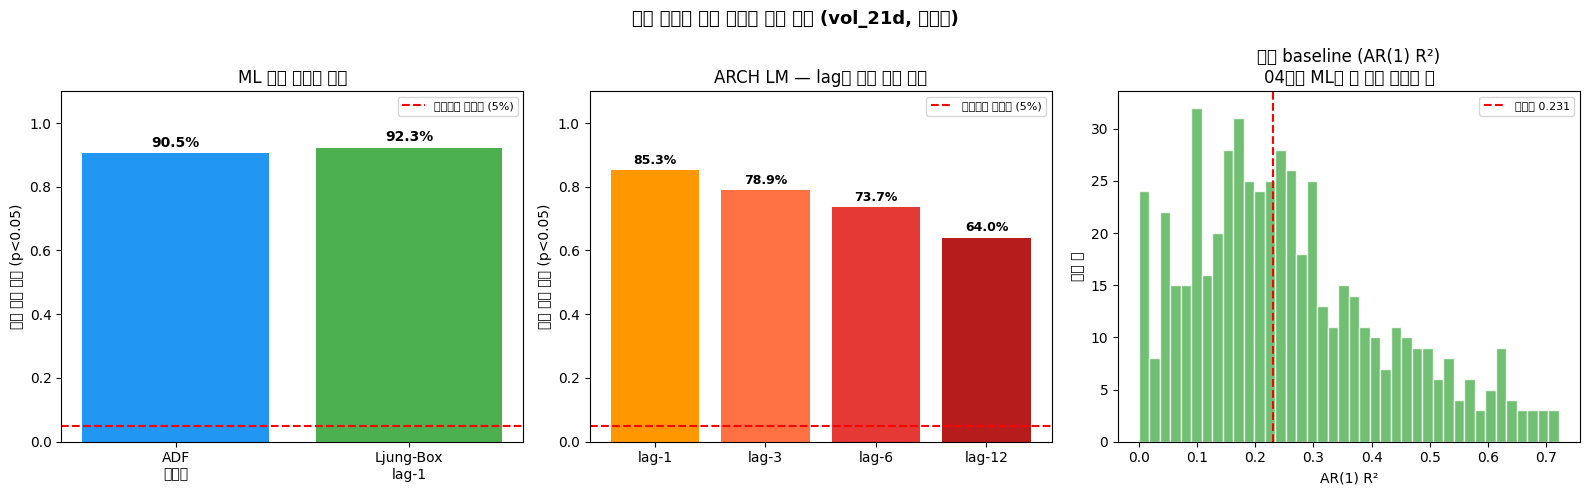

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('월별 변동성 예측 가능성 검정 결과 (vol_21d, 전종목)', fontsize=13, fontweight='bold')

# ① ADF + Ljung-Box 유의 비율
ax = axes[0]
test_names = ['ADF\n정상성', 'Ljung-Box\nlag-1']
ratios = [(res['adf_pval'] < 0.05).mean(), (res['lb1_pval'] < 0.05).mean()]
bars = ax.bar(test_names, ratios, color=['#2196F3', '#4CAF50'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('유의 종목 비율 (p<0.05)')
ax.set_title('ML 적용 타당성 검정')
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='귀무가설 기대치 (5%)')
ax.legend(fontsize=8)
for bar, val in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ② ARCH LM — lag별 유의 비율
ax = axes[1]
arch_ratios = [(res[f'arch_pval_lag{lag}'] < 0.05).mean() for lag in ARCH_LAGS]
lag_labels  = [f'lag-{l}' for l in ARCH_LAGS]
bars = ax.bar(lag_labels, arch_ratios, color=['#FF9800', '#FF7043', '#E53935', '#B71C1C'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('유의 종목 비율 (p<0.05)')
ax.set_title('ARCH LM — lag별 군집 지속 확인')
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='귀무가설 기대치 (5%)')
ax.legend(fontsize=8)
for bar, val in zip(bars, arch_ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ③ AR(1) R² 분포
ax = axes[2]
ax.hist(res['ar1_r2'].dropna(), bins=40, color='#4CAF50', alpha=0.8, edgecolor='white')
ax.axvline(res['ar1_r2'].median(), color='red', linestyle='--',
           label=f'중앙값 {res["ar1_r2"].median():.3f}')
ax.set_xlabel('AR(1) R²')
ax.set_ylabel('종목 수')
ax.set_title('선형 baseline (AR(1) R²)\n04에서 ML이 이 값을 넘어야 함')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'vol_predictability.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
print('=' * 60)
print('03 결론: ML 적용 타당성')
print('=' * 60)

arch_lag1_ratio = (res['arch_pval_lag1'] < 0.05).mean()
arch_lag6_ratio = (res['arch_pval_lag6'] < 0.05).mean()

print(f'''
✓ 정상성    : {(res["adf_pval"] < 0.05).mean():.1%} 종목 확인 → ML 회귀 적용 가능
✓ 자기상관   : {(res["lb1_pval"] < 0.05).mean():.1%} 종목 확인 → 예측 가능한 패턴 존재
✓ ARCH 효과 : lag-1 {arch_lag1_ratio:.1%} / lag-6 {arch_lag6_ratio:.1%} 종목 확인 → ML이 단순 평균보다 나은 근거

  → 월별 변동성은 ML로 예측할 수 있는 통계적 구조를 가진다.

참고
  선형 자기상관: PACF 중앙값 {res["pacf_cutoff"].median():.0f}개월 (선형 구조 참고용)
  AR(1) R²:      중앙값 {res["ar1_r2"].median():.3f} (04에서 ML의 baseline)

미결 사항 → 04_VolatilityPrediction에서 검증
  - 최적 입력 창 (몇 개월)
  - ML 예측 성능이 AR(1) R² 중앙값({res["ar1_r2"].median():.3f})을 초과하는지
''')

03 결론: ML 적용 타당성

✓ 정상성    : 90.5% 종목 확인 → ML 회귀 적용 가능
✓ 자기상관   : 92.3% 종목 확인 → 예측 가능한 패턴 존재
✓ ARCH 효과 : lag-1 85.3% / lag-6 73.7% 종목 확인 → ML이 단순 평균보다 나은 근거

  → 월별 변동성은 ML로 예측할 수 있는 통계적 구조를 가진다.

참고
  선형 자기상관: PACF 중앙값 3개월 (선형 구조 참고용)
  AR(1) R²:      중앙값 0.231 (04에서 ML의 baseline)

미결 사항 → 04_VolatilityPrediction에서 검증
  - 최적 입력 창 (몇 개월)
  - ML 예측 성능이 AR(1) R² 중앙값(0.231)을 초과하는지

